## Neural Network from Scratch (NumPy)

Build a simple fully connected network using only NumPy to classify MNIST digits.

### Dataset
- [Kaggle Digit Recognizer](https://www.kaggle.com/competitions/digit-recognizer/data)
- Download `train.csv` and place it in this folder.


### Imports

Load NumPy, Pandas, and Matplotlib.


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Load Dataset

Read `train.csv` from disk.


In [6]:
data = pd.read_csv("train.csv")

### Preview Data

Quick sanity check of the raw CSV.


In [7]:
data.head(5)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Shuffle and Shape

Convert to NumPy, inspect shape, and shuffle rows.


In [8]:
data = np.array(data)
m, n = data.shape
np.random.shuffle(data)

m,n


(42000, 785)

### Dev Split

Create a small validation split.


In [9]:
data_dev = data[:1000].T
Y_dev = data_dev[0]
X_dev = data_dev[1:n]

print(Y_dev.shape)
print(X_dev.shape)

(1000,)
(784, 1000)


### Training Split

Create the training split.


In [10]:
data_train = data[1000:m].T
Y_train = data_train[0]
X_train = data_train[1:n]


In [11]:
print(Y_train.shape)
print(X_train.shape)

(41000,)
(784, 41000)


### Initialize Parameters

He initialization for weights, zeros for biases.


In [12]:
def init_params():
    w1 = np.random.randn(10, 784) * np.sqrt(2/784)
    b1 = np.zeros((10,1))
    w2 = np.random.randn(10,10) * np.sqrt(2/10)
    b2 = np.zeros((10,1))

    return w1,b1,w2,b2

### Activations

Define ReLU and softmax.


In [13]:
def ReLU(z):
    #replaces all the negative values with zero and returns 0 or returns z is greater than 0
    return np.maximum(0,z)

def softmax(z):
    # Subtracting the max for numerical stability
    exp_z = np.exp(z - np.max(z, axis=0, keepdims=True))
    return exp_z / np.sum(exp_z, axis=0, keepdims=True)

### Forward Propagation

Compute activations for each layer.


In [14]:
def forward_prop(w1,b1,w2,b2,X):
    z1 = np.dot(w1,X) + b1
    a1 = ReLU(z1)
    z2 = np.dot(w2,a1) + b2
    a2 = softmax(z2)

    return z1,a1,z2,a2

### One-Hot Encoding

Convert labels into one-hot vectors.


In [15]:
def one_hot(y):
    one_hot_y = np.zeros((y.size,y.max()+1))
    one_hot_y[np.arange(y.size),y] = 1
    one_hot_y = one_hot_y.T
    return one_hot_y

### ReLU Derivative

Gradient of ReLU for backprop.


In [16]:
def deriv_ReLU(z):
    return z > 0

### Backward Propagation

Compute gradients with respect to parameters.


In [17]:
def backward_prop(w1,w2,z1,z2,a1,a2,X,Y):
    one_hot_y = one_hot(Y)
    dz2 = a2 - one_hot_y
    dw2 = 1 / m * np.dot(dz2,a1.T)
    db2 = 1 / m * np.sum(dz2)
    dz1 = np.dot(w2,dz2) * deriv_ReLU(z1)
    dw1 = 1 / m * np.dot(dz1, X.T)
    db1 = 1 / m * np.sum(dz1)

    return dw1,db1,dw2,db2

### Parameter Updates

Apply gradient descent update.


In [18]:
def update_params(w1,b1,w2,b2,dw1,db1,dw2,db2,alpha):
    w1 = w1 - alpha * dw1
    b1 = b1 - alpha * db1
    w2 = w2 - alpha * dw2
    b2 = b2 - alpha * db2

    return w1,b1,w2,b2

### Metrics

Prediction and accuracy helpers.


In [19]:
def get_predictions(a2):
    return np.argmax(a2,0)

def get_accuracy(predictions,Y):
    return np.sum(predictions == Y) / Y.size

### Training Loop

Run forward + backward passes over epochs.


In [20]:
def gradient_descent(X,Y, alpha,num_iters):
    w1,b1,w2,b2 = init_params()
    for i in range(num_iters):
        z1,a1,z2,a2 = forward_prop(w1,b1,w2,b2,X)
        dw1,db1,dw2,db2 = backward_prop(w1,w2,z1,z2,a1,a2,X,Y)
        w1,b1,w2,b2 = update_params(w1,b1,w2,b2,dw1,db1,dw2,db2, alpha)

        if i % 10 == 0:
            print("Iteration: ", i)
            # print(f"Updated params: w1: {w1}, b1: {b1}, w2: {w2}, and b2: {b2}")
            print(f"prediction ---> {get_predictions(a2)}, and actual target value --> {Y}")
            print(f"accuracy --> {(get_accuracy(get_predictions(a2),Y))}")

    return w1,b1,w2,b2

### Normalize Inputs

Scale pixel values to [0, 1].


In [21]:
X_train = X_train / 255
X_dev = X_dev / 255

### Training (Gradient Descent)

Run full-batch gradient descent and monitor training accuracy.


### Train Model

Fit the model using gradient descent.


In [22]:
w1, b1, w2, b2 = gradient_descent(X_train, Y_train, 0.1, 1000)

Iteration:  0
prediction ---> [2 9 9 ... 9 9 9], and actual target value --> [1 9 6 ... 7 9 0]
accuracy --> 0.14317073170731706
Iteration:  10
prediction ---> [3 6 6 ... 3 2 5], and actual target value --> [1 9 6 ... 7 9 0]
accuracy --> 0.16963414634146343
Iteration:  20
prediction ---> [9 2 6 ... 7 9 0], and actual target value --> [1 9 6 ... 7 9 0]
accuracy --> 0.29585365853658535
Iteration:  30
prediction ---> [1 9 6 ... 7 9 6], and actual target value --> [1 9 6 ... 7 9 0]
accuracy --> 0.4561707317073171
Iteration:  40
prediction ---> [1 9 6 ... 7 9 6], and actual target value --> [1 9 6 ... 7 9 0]
accuracy --> 0.6285853658536585
Iteration:  50
prediction ---> [5 9 6 ... 7 9 6], and actual target value --> [1 9 6 ... 7 9 0]
accuracy --> 0.6940243902439024
Iteration:  60
prediction ---> [5 9 6 ... 7 9 6], and actual target value --> [1 9 6 ... 7 9 0]
accuracy --> 0.7390487804878049
Iteration:  70
prediction ---> [5 9 6 ... 7 9 6], and actual target value --> [1 9 6 ... 7 9 0]
accura

### Prediction Helper

Generate predictions for a batch.


In [23]:
def make_prediction(X, w1, b1, w2, b2):
    _, _, _, a2 = forward_prop(w1,b1,w2,b2, X)
    return get_predictions(a2)

### Evaluation on Dev Set

Check accuracy on the held-out dev split.


### Evaluate on Dev Set

Compute accuracy on the dev split.


In [24]:
dev_pred = make_prediction(X_dev, w1,b1,w2,b2)
print(get_accuracy(dev_pred,Y_dev))


0.906


### Visualize Predictions

Inspect individual predictions and images.


In [25]:
def test_prediction(i, w1,b1,w2,b2):
    current_image = X_train[:,i,None]
    predict = make_prediction(current_image, w1,b1,w2,b2)
    label = Y_train[i]

    print(f"Prediction: {predict}")
    print(f"Label: {label}")

    current_image = current_image.reshape((28,28))  * 255
    plt.gray()
    plt.imshow(current_image, interpolation = "nearest")
    plt.show()

Prediction: [6]
Label: 6


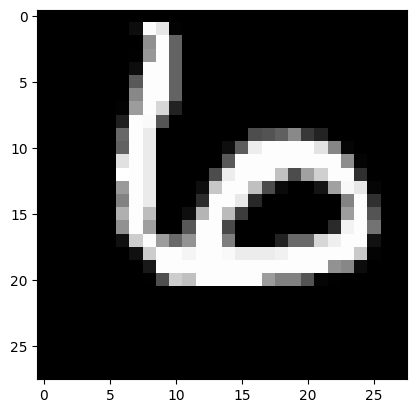

In [26]:
test_prediction(2,w1,b1,w2,b2)

Prediction: [0]
Label: 0


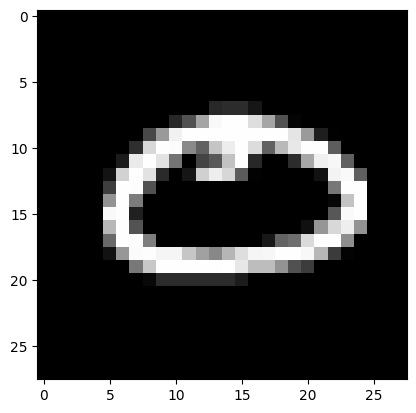

In [27]:
test_prediction(4,w1,b1,w2,b2)

Prediction: [0]
Label: 0


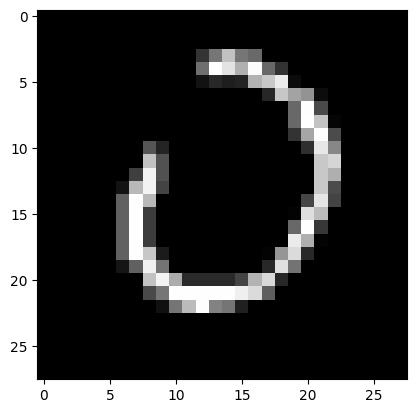

In [28]:
test_prediction(7,w1,b1,w2,b2)